# Module 3: K-Means Customer Segmentation
**Customer Intelligence Platform**

Goal: cluster customers into behavior-based segments using the scaled RFM + extended features from Module 2, then interpret each cluster in business terms.

## Step 1: Load Scaled Features

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

scaled_features = pd.read_csv('../data/processed/customer_features_scaled.csv')
customer_features = pd.read_csv('../data/processed/customer_features.csv')

print(f'Shape (row, col): {scaled_features.shape}')

Shape (row, col): (5878, 8)


In [2]:
print(f'columns : {scaled_features.columns}')
scaled_features.head()

columns : Index(['Customer ID', 'Recency', 'Frequency_log', 'Monetary_log', 'Tenure',
       'AOV_log', 'Purchase_Variability_log', 'Product_Diversity_log'],
      dtype='object')


,Customer ID,Recency,Frequency_log,Monetary_log,Tenure,AOV_log,Purchase_Variability_log,Product_Diversity_log
0,12346.0,0.595584,1.254496,3.186625,0.490667,4.264242,0.982440,-0.350753
1,12347.0,-0.952279,0.800166,1.297127,0.498395,1.253001,0.397709,0.889667
2,12348.0,-0.603532,0.299207,0.558100,0.343827,0.498904,0.922140,-0.411550
3,12349.0,-0.871064,0.073946,1.123790,1.147582,1.867373,1.490062,0.963738
4,12350.0,0.519146,-1.058146,-0.735888,-1.055014,0.243026,-1.064573,-0.713229


**Important:** `Customer ID` is an identifier, not a behavioral feature — it must **not** be passed into K-Means. If it is, its large raw magnitude dominates the Euclidean distance calculation and the clustering ends up grouping customers by ID number rather than by actual behavior. We explicitly select only the 7 real feature columns before fitting anything below.

In [3]:
feature_cols = ['Recency', 'Frequency_log', 'Monetary_log', 'Tenure',
                'AOV_log', 'Purchase_Variability_log', 'Product_Diversity_log']
X = scaled_features[feature_cols]

## Step 2: Elbow Method

In [4]:
wcss = []

for k in range(2, 11):
    k_means = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_means.fit(X)
    wcss.append(k_means.inertia_)

for key, value in zip(range(2, 11), wcss):
    print(f'{key} : {value:.4f}')

2 : 22002.1897
3 : 18219.6617
4 : 15217.3208
5 : 13678.7794
6 : 12558.9959
7 : 11604.9285
8 : 10830.8351
9 : 10206.9645
10 : 9611.9597


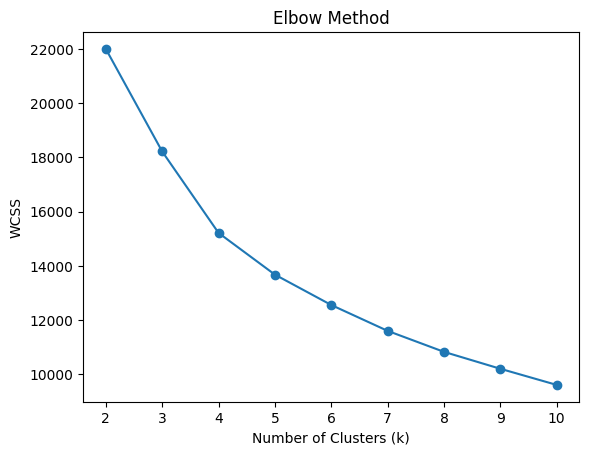

In [5]:
plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.savefig('../images/elbow_method.png', dpi=100)
plt.show()

## Step 3: Silhouette Score

In [6]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.4050
k=3, Silhouette Score=0.2957
k=4, Silhouette Score=0.2600
k=5, Silhouette Score=0.2570
k=6, Silhouette Score=0.2276
k=7, Silhouette Score=0.2271
k=8, Silhouette Score=0.2262
k=9, Silhouette Score=0.2267
k=10, Silhouette Score=0.2276


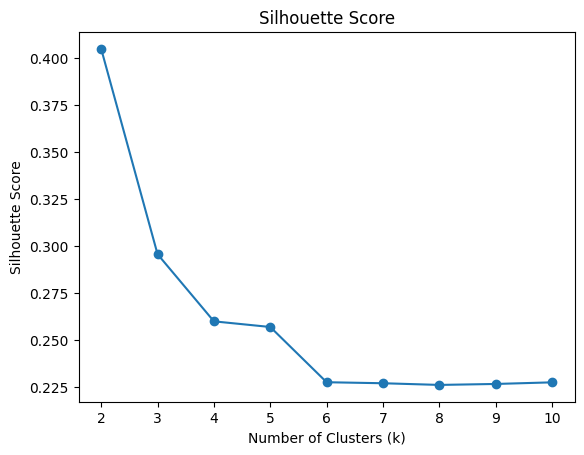

In [7]:
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.savefig('../images/silhouette_scores_plot.png', dpi=100)
plt.show()

**Choosing k:** the silhouette score is technically highest at k=2 (~0.41), which makes sense — splitting customers into just 2 broad groups is always the 'easiest' separation. But 2 clusters isn't very actionable for a business (just 'engaged' vs 'not'). The elbow plot's rate of drop clearly slows down around **k=4–5**, and the silhouette score there (~0.26) is still reasonable and only slightly below k=2 or k=3. Since the project goal is to produce interpretable, business-actionable segments (e.g. loyal customers, at-risk, new, lost), **k=4** is chosen — it balances statistical separation with practical usefulness.

## Step 4: Fit Final K-Means Model

In [8]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X)
pd.Series(cluster_labels).value_counts().sort_index()

0    1437
1    1341
2    1271
3    1829
Name: count, dtype: int64

## Step 5: Assign Clusters to Customer Data

In [9]:
customer_features = customer_features.copy()
customer_features['Cluster'] = cluster_labels

## Step 6: Profile & Interpret Clusters

Group by cluster and compute mean Recency, Frequency, Monetary, Tenure, AOV, etc per cluster. Use these averages to label each cluster in business terms — e.g. 'loyal high-spenders', 'at-risk', 'new customers', 'one-time buyers'. This step is where K-Means actually becomes useful, not just a math exercise.

In [10]:
cluster_profile = (customer_features.groupby('Cluster')
                    [['Recency', 'Frequency', 'Monetary', 'Tenure', 'AOV',
                      'Purchase_Variability', 'Product_Diversity']]
                    .mean().round(2))
cluster_size = customer_features['Cluster'].value_counts().sort_index().rename('Customer_Count')
cluster_profile = cluster_profile.join(cluster_size)
cluster_profile

,Recency,Frequency,Monetary,Tenure,AOV,Purchase_Variability,Product_Diversity,Customer_Count
Cluster,,,,,,,,
0,211.80,1.62,938.38,91.88,579.66,0.29,39.59,1437
1,46.10,17.92,10198.64,591.18,545.27,50.07,208.73,1341
2,431.51,1.33,207.59,27.07,165.20,1.17,14.32,1271
3,146.97,4.88,1342.13,352.98,288.91,87.58,69.39,1829


**Reading the profile:**
- **Cluster 1** — lowest Recency (~46 days), highest Frequency (~18), highest Monetary (~10,199), longest Tenure (~591 days), widest Product_Diversity (~209) → **Loyal High-Value Customers**
- **Cluster 0** — short Tenure (~92 days), low Frequency (~1.6), but a notably high AOV (~580), near-zero purchase variability (barely enough orders to vary) → **New / Occasional Big-Ticket Buyers**
- **Cluster 3** — long Tenure (~353 days), moderate spend, but the highest Purchase_Variability (~88, irregular buying pattern) and rising Recency (~147 days) → **At-Risk Regulars**
- **Cluster 2** — highest Recency (~432 days — over a year since last purchase), lowest Frequency, Monetary, and Product_Diversity across the board → **Lost / Churned Customers**

In [ ]:
segment_names = {
    0: 'New / Occasional Big-Ticket Buyers',
    1: 'Loyal High-Value Customers',
    2: 'Lost / Churned Customers',
    3: 'At-Risk Regulars'}
customer_features['Segment_Name'] = customer_features['Cluster'].map(segment_names)
customer_features[['Customer ID', 'Cluster', 'Segment_Name']].head()

,Customer ID,Cluster,Segment_Name
0,12346.0,1,Loyal High-Value Customers
1,12347.0,1,Loyal High-Value Customers
2,12348.0,3,At-Risk Regulars
3,12349.0,1,Loyal High-Value Customers
4,12350.0,0,New / Occasional Big-Ticket Buyers


## Step 7: Visualize Clusters with PCA

In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total variance captured:', pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.62027712 0.16038742]
Total variance captured: 0.780664543973066


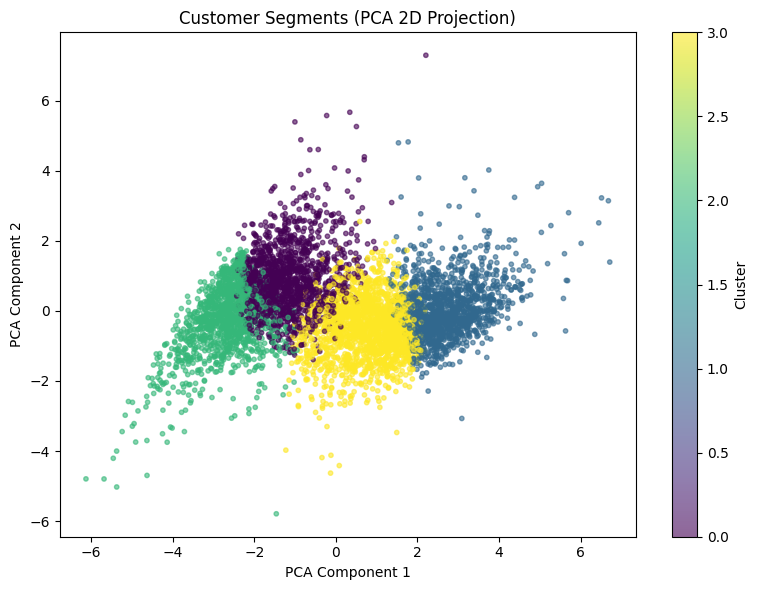

array([1, 1, 3, ..., 2, 0, 1], shape=(5878,), dtype=int32)

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=10)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments (PCA 2D Projection)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('../images/pca_clusters.png', dpi=100)
plt.show()


The 2 PCA components together explain roughly **78%** of the total variance, so this 2D view is a fairly trustworthy summary of the real 7D clustering 

## Step 8: Save Model & Segmented Data

In [14]:
# Save the trained KMeans model for reuse in the FastAPI service
joblib.dump(final_kmeans, '../models/kmeans_model.pkl')

# Save the customer table with cluster labels + segment names for Module 4 (churn labeling)
customer_features.to_csv('../data/processed/customer_segments.csv', index=False)

print('Saved kmeans_model.pkl to models/')
print('Saved customer_segments.csv to data/processed/')

Saved kmeans_model.pkl to models/
Saved customer_segments.csv to data/processed/


### Module 3 Summary

- Elbow + Silhouette analysis run for k=2 to 10; silhouette peaks at k=2 (~0.41) but flattens out from k=4 onward — **k=4** chosen for a balance of statistical support and business interpretability.
- Final 4 segments identified and named:
  - **Loyal High-Value Customers** (1,341) — most recent, most frequent, highest spend
  - **At-Risk Regulars** (1,829) — long-tenured but increasingly irregular and drifting
  - **New / Occasional Big-Ticket Buyers** (1,437) — short tenure, few orders, high order value
  - **Lost / Churned Customers** (1,271) — inactive for 400+ days on average
- PCA 2D projection (78% variance explained) used as a visual sanity check of cluster separation
- Saved `kmeans_model.pkl` to `models/` and `customer_segments.csv` to `data/processed/` — ready for Module 4 (churn labeling) and the FastAPI `/segment` endpoint